# **Importing Libraries & Loading Dataset**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

xls = pd.ExcelFile("online_retail_II.xlsx")
df1 = pd.read_excel(xls, sheet_name="Year 2009-2010")
df2 = pd.read_excel(xls, sheet_name="Year 2010-2011")
df = pd.concat([df1, df2], ignore_index=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.dtypes)
df.head()

Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# **Handling Missing Values & Duplicates**

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(report[report.missing_count > 0])

dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")

print("Negative Quantity rows:", (df.Quantity < 0).sum())
print("Zero/negative Price rows:", (df.Price <= 0).sum())
print("Cancelled invoices (start with C):", df.Invoice.astype(str).str.startswith("C").sum())

             missing_count  missing_pct
Description           4382         0.41
Customer ID         243007        22.77
Duplicate rows: 34335 (3.22%)
Negative Quantity rows: 22950
Zero/negative Price rows: 6207
Cancelled invoices (start with C): 19494


# **Revenue + top products**

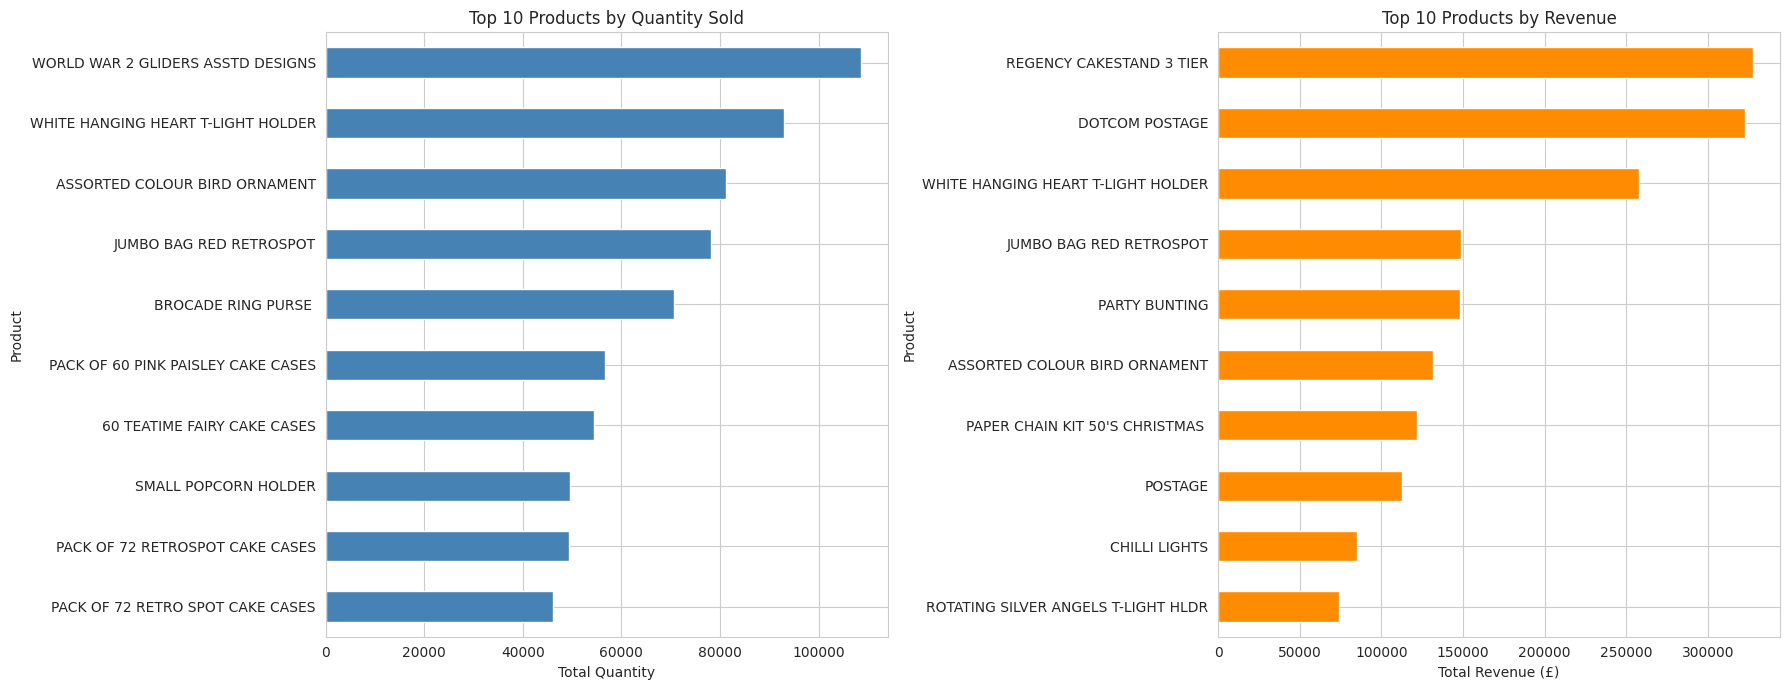

In [6]:
df["Revenue"] = df["Quantity"] * df["Price"]

top_qty = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_rev = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top_qty.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Products by Quantity Sold")
axes[0].set_xlabel("Total Quantity"); axes[0].set_ylabel("Product")

top_rev.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 Products by Revenue")
axes[1].set_xlabel("Total Revenue (£)"); axes[1].set_ylabel("Product")
plt.tight_layout()
plt.show()

# **Sales by country**

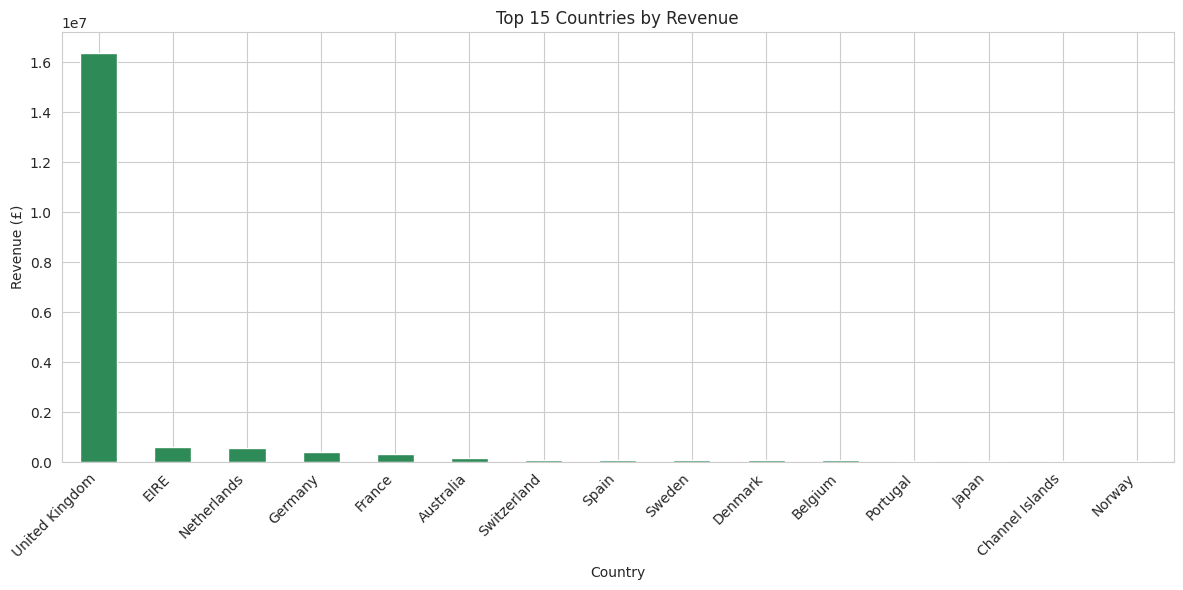

In [7]:
country_rev = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
country_rev.plot(kind="bar", color="seagreen")
plt.title("Top 15 Countries by Revenue")
plt.xlabel("Country"); plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **Monthly revenue trend**

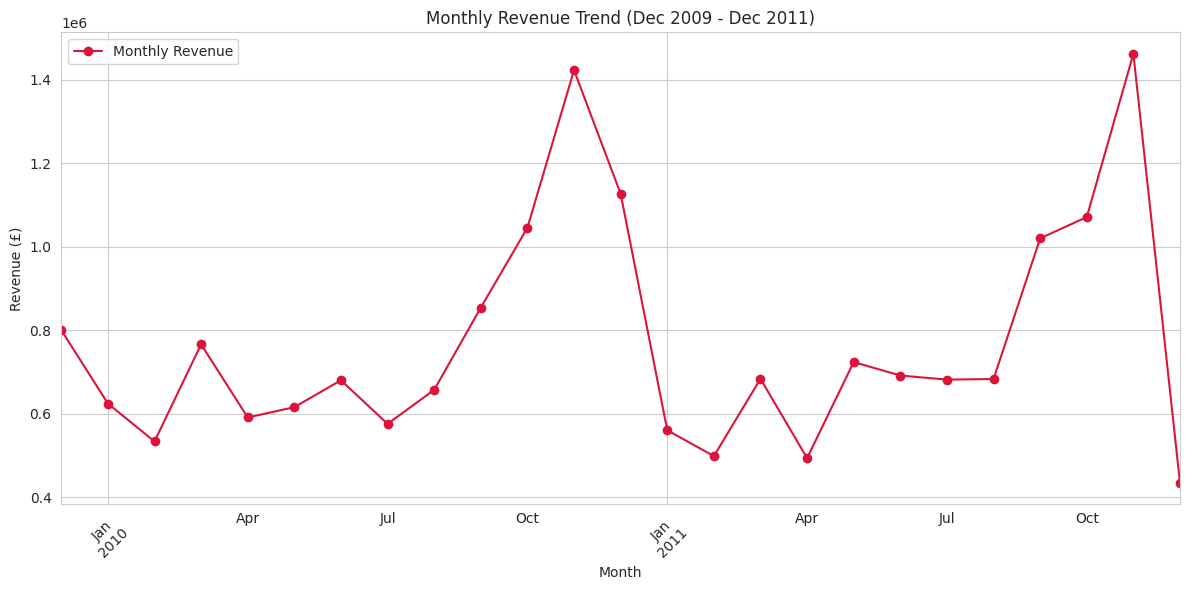

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_rev = df.groupby("YearMonth")["Revenue"].sum()

plt.figure(figsize=(12,6))
monthly_rev.plot(kind="line", marker="o", color="crimson", label="Monthly Revenue")
plt.title("Monthly Revenue Trend (Dec 2009 - Dec 2011)")
plt.xlabel("Month"); plt.ylabel("Revenue (£)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Correlation heatmap**

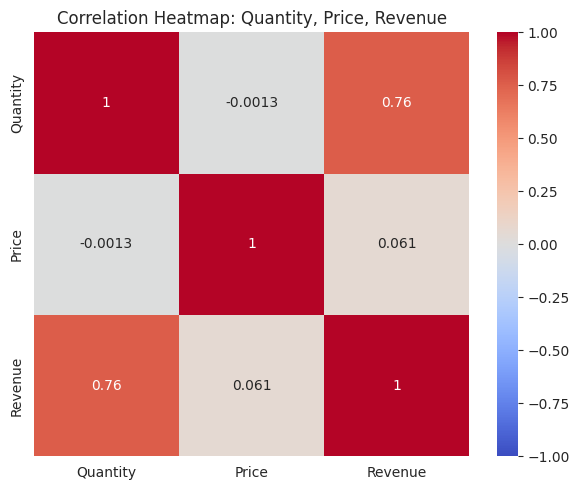

In [9]:
numeric_cols = df[["Quantity", "Price", "Revenue"]]
corr = numeric_cols.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Quantity, Price, Revenue")
plt.tight_layout()
plt.show()

# **Outlier boxplots**

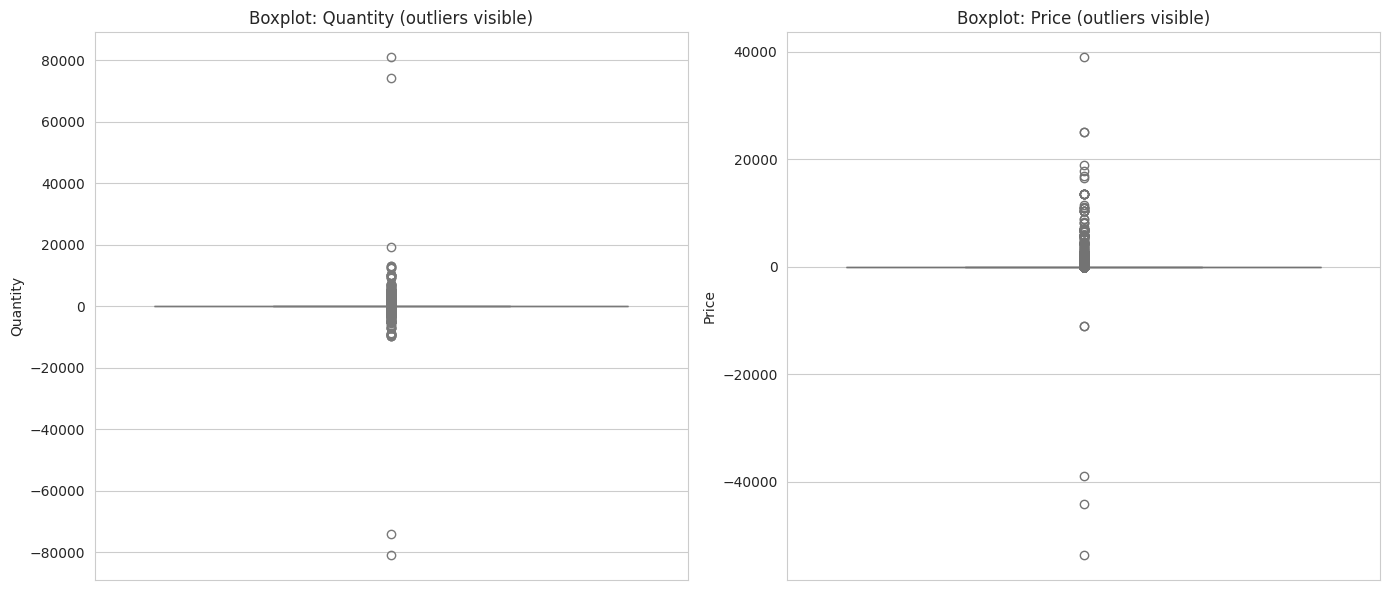

Quantity: 116489 outliers outside [-12.50, 23.50]
Price: 68105 outliers outside [-3.10, 8.50]


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(y=df["Quantity"], ax=axes[0], color="lightblue")
axes[0].set_title("Boxplot: Quantity (outliers visible)")
axes[0].set_ylabel("Quantity")

sns.boxplot(y=df["Price"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot: Price (outliers visible)")
axes[1].set_ylabel("Price")
plt.tight_layout()
plt.show()

for col in ["Quantity", "Price"]:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers outside [{lower:.2f}, {upper:.2f}]")

# **Customer Analysis**


Unique customers (excluding missing IDs): 5942
Transaction rows with no Customer ID: 243007 (22.77%)


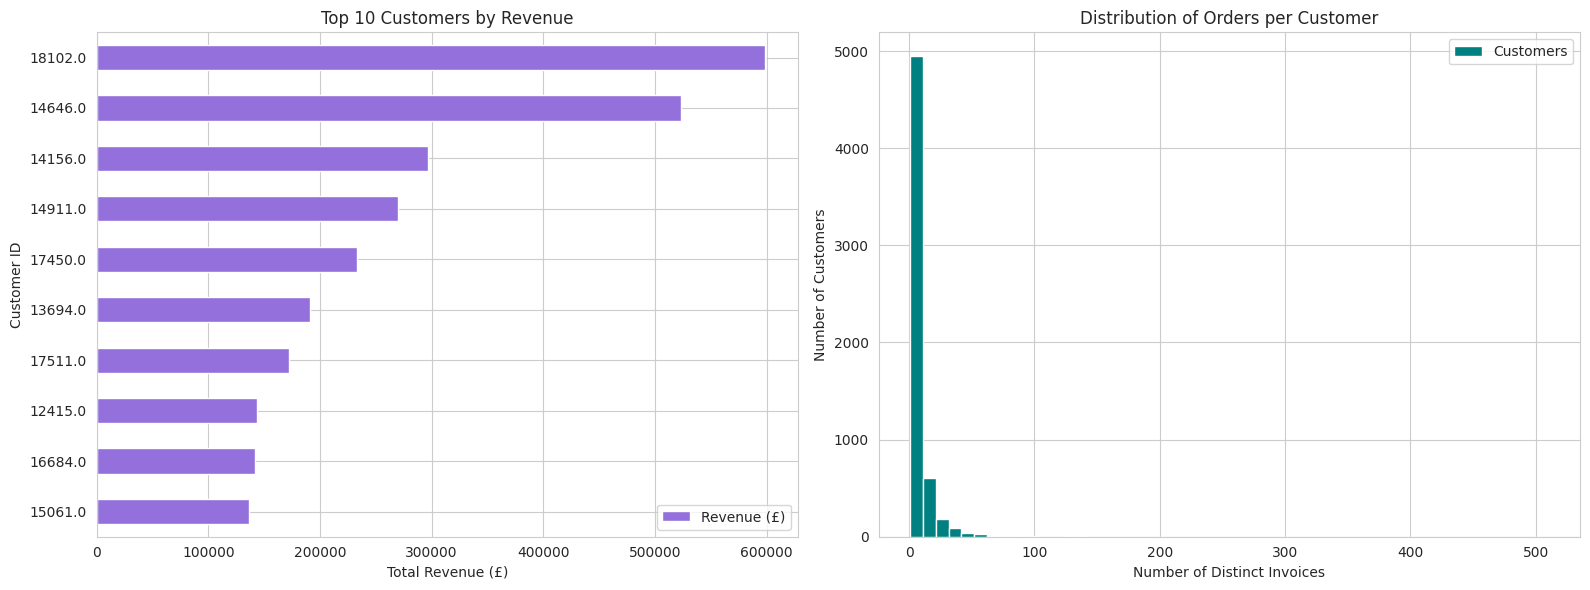

Top 10 customers account for 16.25% of revenue from identified customers
Median orders per customer: 4.0, Max orders by a single customer: 510


In [11]:
n_customers = df["Customer ID"].nunique()
n_missing_cust = df["Customer ID"].isnull().sum()
print(f"Unique customers (excluding missing IDs): {n_customers}")
print(f"Transaction rows with no Customer ID: {n_missing_cust} ({n_missing_cust/len(df)*100:.2f}%)")

cust_rev = df.dropna(subset=["Customer ID"]).groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)
top10_cust = cust_rev.head(10)

orders_per_cust = df.dropna(subset=["Customer ID"]).groupby("Customer ID")["Invoice"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(16,6))

top10_cust.sort_values().plot(kind="barh", ax=axes[0], color="mediumpurple", label="Revenue (£)")
axes[0].set_title("Top 10 Customers by Revenue")
axes[0].set_xlabel("Total Revenue (£)"); axes[0].set_ylabel("Customer ID")
axes[0].legend()

axes[1].hist(orders_per_cust, bins=50, color="teal", label="Customers")
axes[1].set_title("Distribution of Orders per Customer")
axes[1].set_xlabel("Number of Distinct Invoices"); axes[1].set_ylabel("Number of Customers")
axes[1].legend()

plt.tight_layout()
plt.show()

top10_share = top10_cust.sum() / cust_rev.sum() * 100
print(f"Top 10 customers account for {top10_share:.2f}% of revenue from identified customers")
print(f"Median orders per customer: {orders_per_cust.median()}, Max orders by a single customer: {orders_per_cust.max()}")

# **Business Insights**

Based on the exploration above, here are the key takeaways for the business:

1. **Data quality needs attention before modeling.** ~22.8% of transaction rows have no Customer ID, and 3.22% of rows are exact duplicates. Any recommendation system built on this data will silently lose almost a quarter of transactions unless this is resolved (e.g., guest checkout tagging, ID imputation, or a policy decision to exclude anonymous orders).

2. **Cancellations and negative quantities are material, not noise.** Nearly 19,500 invoices are cancellations (prefixed "C") and over 22,900 rows have negative quantities. These should be modeled as a distinct "returns/cancellations" signal rather than treated as errors, since they likely reflect real customer behavior (e.g., product dissatisfaction) that a recommendation engine should avoid reinforcing.

3. **Revenue is heavily product-concentrated.** A small number of SKUs dominate both quantity sold and revenue generated, suggesting the catalog has a clear set of "hero products." A recommendation system should ensure it doesn't just repeatedly surface these bestsellers at the expense of long-tail discovery, which is often where recommender systems add the most incremental value.

4. **The business is highly dependent on a single market.** The United Kingdom dominates total revenue among all countries sold to, meaning international markets are comparatively under-penetrated. This is either a risk (revenue concentration) or an opportunity (room to grow abroad), depending on strategic intent.

5. **Revenue shows clear seasonality.** The monthly revenue trend shows visible peaks (notably around Q4 / holiday season) and troughs, meaning any demand forecasting or recommendation logic should account for time-of-year effects rather than assuming stable, uniform demand.

6. **Customer spend is concentrated in a small group of high-value buyers.** The top 10 identified customers account for a disproportionate share of total revenue, indicating the business relies on a loyal core of repeat/bulk buyers (likely wholesale or business accounts) rather than a broad base of casual one-time shoppers. A recommendation system may need separate treatment for these high-frequency accounts versus typical retail customers.

7. **Quantity and Price both contain extreme outliers.** IQR-based detection flags well over 100,000 rows in Quantity and tens of thousands in Price as outliers, consistent with a mix of bulk/wholesale orders and likely data entry errors. These extremes should be investigated (not removed at this stage per task instructions) before they are allowed to skew any downstream statistical or ML model.